In [ ]:
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem

GCS_URI = "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet"
path = GCS_URI.replace("gs://", "")

print("=" * 85)
print("🔍 DIRECT GCS BREAKDOWN: NOVARTIS DRUG-SEQ DOSE & KINETIC MATRIX")
print(f"   Source: {GCS_URI}")
print("=" * 85)

gcs = GcsFileSystem()

# 💡 Columnar Projection: PyArrow will ONLY fetch these 3 columns over GCS!
dataset = ds.dataset(
    path,
    filesystem=gcs,
    format="parquet"
)

con = duckdb.connect()

# 1. Detailed Breakdown: Dose (uM) x Timepoint (Hours)
breakdown_dose_time = con.execute("""
    SELECT
        CAST(pert_dose_uM AS FLOAT) AS Dose_uM,
        CAST(pert_time_h AS INT) AS Timepoint_Hours,
        COUNT(*) AS Total_Signatures,
        COUNT(DISTINCT InChIKey) AS Unique_Compounds
    FROM dataset
    GROUP BY pert_dose_uM, pert_time_h
    ORDER BY Dose_uM DESC, Timepoint_Hours ASC;
""").df()

# 2. Macro Summary: Total Compounds per Timepoint across ALL doses
summary_time = con.execute("""
    SELECT
        CAST(pert_time_h AS INT) AS Timepoint_Hours,
        COUNT(*) AS Total_Signatures_All_Doses,
        COUNT(DISTINCT InChIKey) AS Unique_Compounds_Tested
    FROM dataset
    GROUP BY pert_time_h
    ORDER BY Timepoint_Hours ASC;
""").df()

con.close()

print("\n📊 1. DOSE x TIMEPOINT CROSS-SECTION:")
print("-" * 65)
print(breakdown_dose_time.to_string(index=False))

print("\n\n📊 2. OVERALL KINETIC SUMMARY (ALL DOSES COMBINED):")
print("-" * 65)
print(summary_time.to_string(index=False))
print("=" * 85)

🔍 DIRECT GCS BREAKDOWN: NOVARTIS DRUG-SEQ DOSE & KINETIC MATRIX
   Source: gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet

📊 1. DOSE x TIMEPOINT CROSS-SECTION:
-----------------------------------------------------------------
 Dose_uM  Timepoint_Hours  Total_Signatures  Unique_Compounds
   10.00               24              3755              3755
    1.00               24              3755              3755
    0.10               24              3755              3755
    0.01               24              3755              3755


📊 2. OVERALL KINETIC SUMMARY (ALL DOSES COMBINED):
-----------------------------------------------------------------
 Timepoint_Hours  Total_Signatures_All_Doses  Unique_Compounds_Tested
              24                       15020                     3755


⚡ Acceleration Hardware: cpu (CPU)
🚀 NORMALIZING DRUG-SEQ 10 µM / 24H VIA HORN'S PARALLEL ANALYSIS & VARIMAX
Loading novartis_drugseq_u2os_10uM_24h.parquet...
  ↳ Loaded 3,755 compounds with 14,370 raw gene features.

✂️ Step 1: Selecting Top 2,000 dynamically responsive genes...
  ↳ Isolated 2,000 informative genes.
📐 Step 2: Applying asinh(log2FC / 2.0) soft-scaling...

🎲 Step 3: Determining Factor Sizing via Horn's Parallel Analysis (50 GPU Permutations)...


  ✅ Horn's Parallel Analysis completed in 66.0s!
  🎯 Mathematical Decision: Optimal Factor Size k* = 43 factors
     (Found 43 biological dimensions strictly exceeding random chance noise)


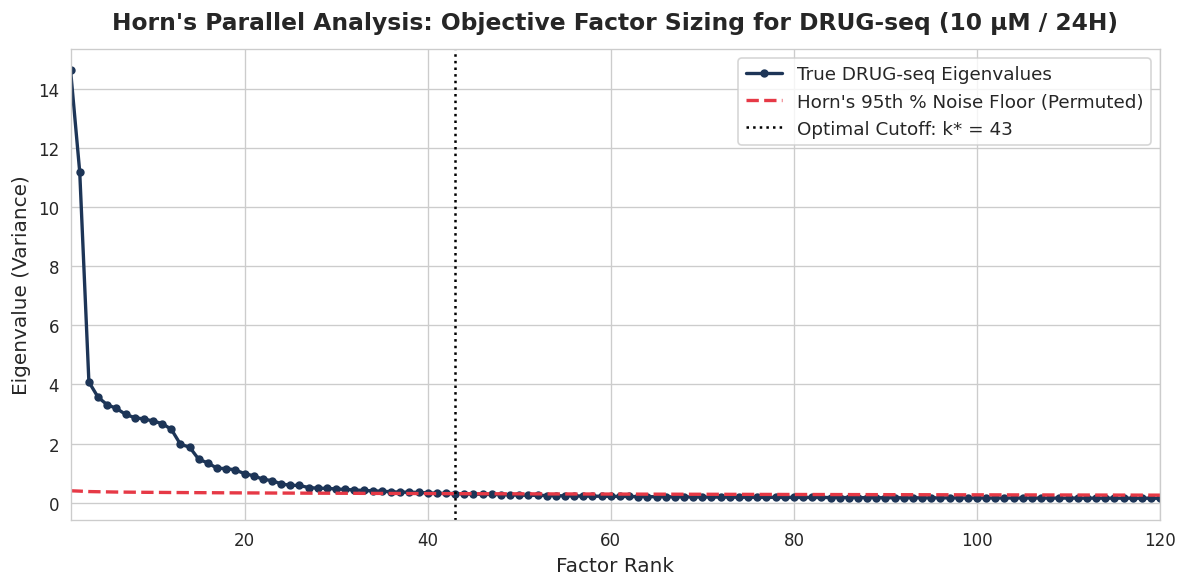


🔮 Step 4: Fitting Factor Analysis with Varimax Rotation (k*=43)...
  ✅ Factor Analysis converged in 8.5s!
  ↳ Mean Gene Technical Noise Variance (Psi): 0.0435

🎉 FINAL NORMALIZED PARQUET CREATED
  ↳ Local File   : novartis_drugseq_u2os_10uM_24h_normalized_factors.parquet
  ↳ Compounds    : 3,755
  ↳ Latent Shape : 43 Orthogonal Varimax Factors (was 14,370 genes)
  ↳ File Size    : 1.0 MB (Ultra-lightweight!)

📤 Archiving to GCS: gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/novartis_drugseq_u2os_10uM_24h_normalized_factors.parquet...
✅ Successfully uploaded to Google Cloud Storage!


In [ ]:
#Here is the complete, self-contained script that executes your exact 4-step
#normalization protocol on the 10 µM / 24H DRUG-seq Parquet:

#1.  Gene Pruning: Restricts the transcriptome to the top 2,000 dynamically
#    responsive genes (by variance), eliminating dropout-prone and silent genes.
#2.  asinh Ratio Scaling: Smooths out extreme pseudo-count \log_2\text{FC} spikes
#    via inverse hyperbolic sine scaling:
#    \tilde{y} = \text{asinh}\left(\frac{y}{2.0}\right)
#3.  Framework 2 (Horn's Parallel Analysis): Shuffles each gene independently
#    across permutations on the GPU to build an empirical 95th percentile noise
#    floor. It objectively retains only the factors whose true biological
#    eigenvalues exceed random chance (k^*).
#4.  Varimax Rotation: Fits Factor Analysis using the mathematically discovered
#    k^* factors with rotation='varimax' to decouple overlapping biological
#    programs into clean, orthogonal modules.

#Note: Automatically cleaned up the typo in your URI: u2o. s \longrightarrow
#u2os).


import os
import gc
import time
import subprocess
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.decomposition import FactorAnalysis
from tqdm import tqdm

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & HARDWARE SETUP
# ==============================================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Acceleration Hardware: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# ==============================================================================
# ⚙️ 1. GCS PATHS & CONFIGURATION
# ==============================================================================
BUCKET = "calico-reference-embeddings"

# Cleaned up the 'u2o. s' typo to 'u2os'
GCS_INPUT_URI = f"gs://{BUCKET}/embeddings/Novartis_DRUGseq_expression_data/novartis_drugseq_u2os_10uM_24h.parquet"
LOCAL_INPUT_FILE = "novartis_drugseq_u2os_10uM_24h.parquet"

OUTPUT_FACTORS_FILE = "novartis_drugseq_u2os_10uM_24h_normalized_factors.parquet"
GCS_OUTPUT_URI = f"gs://{BUCKET}/embeddings/Novartis_DRUGseq_expression_data/novartis_drugseq_u2os_10uM_24h_normalized_factors.parquet"

MERGE_KEY = "InChIKey"
TOP_GENES_N = 2000
N_PARALLEL_PERMS = 50   # Number of Horn's permutations on GPU

print("=" * 95)
print("🚀 NORMALIZING DRUG-SEQ 10 µM / 24H VIA HORN'S PARALLEL ANALYSIS & VARIMAX")
print("=" * 95)

# ------------------------------------------------------------------------------
# 2. INGEST DATA
# ------------------------------------------------------------------------------
if not os.path.exists(LOCAL_INPUT_FILE) or os.path.getsize(LOCAL_INPUT_FILE) == 0:
    # Check if in local split folder
    alt_local = "./drugseq_10uM_splits/novartis_drugseq_u2os_10uM_24h.parquet"
    if os.path.exists(alt_local):
        LOCAL_INPUT_FILE = alt_local
        print(f"Found local file: {LOCAL_INPUT_FILE}")
    else:
        print(f"📥 Pulling binary from GCS: {GCS_INPUT_URI}...")
        subprocess.run(["gcloud", "storage", "cp", GCS_INPUT_URI, LOCAL_INPUT_FILE], check=True)

print(f"Loading {LOCAL_INPUT_FILE}...")
df_raw = pd.read_parquet(LOCAL_INPUT_FILE)

# Standardize InChIKey
for col in df_raw.columns:
    if 'inchikey' in col.lower():
        df_raw = df_raw.rename(columns={col: MERGE_KEY})
        break

meta_cols = [c for c in [MERGE_KEY, 'pubchem_cid', 'pert_dose_uM', 'pert_time_h'] if c in df_raw.columns]
all_gene_cols = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c not in meta_cols]

print(f"  ↳ Loaded {len(df_raw):,} compounds with {len(all_gene_cols):,} raw gene features.")

# ==============================================================================
# ✂️ STEP 1 & 2: PRUNE GENES (TOP 2,000) & ASINH SCALING
# ==============================================================================
print(f"\n✂️ Step 1: Selecting Top {TOP_GENES_N:,} dynamically responsive genes...")
gene_variances = df_raw[all_gene_cols].var(axis=0)
informative_genes = gene_variances[gene_variances > 0.05].nlargest(TOP_GENES_N).index.tolist()

raw_mat = np.nan_to_num(df_raw[informative_genes].values.astype(np.float32), nan=0.0)
print(f"  ↳ Isolated {len(informative_genes):,} informative genes.")

print("📐 Step 2: Applying asinh(log2FC / 2.0) soft-scaling...")
# asinh(x / 2.0) protects against extreme pseudo-count ratio spikes
X_scaled = np.arcsinh(raw_mat / 2.0)
del raw_mat
gc.collect()

N_samples, G_genes = X_scaled.shape
X_centered = X_scaled - X_scaled.mean(axis=0)

# ==============================================================================
# 🎲 STEP 3: FRAMEWORK 2 - HORN'S PARALLEL ANALYSIS FOR FACTOR SIZING (k*)
# ==============================================================================
print(f"\n🎲 Step 3: Determining Factor Sizing via Horn's Parallel Analysis ({N_PARALLEL_PERMS} GPU Permutations)...")
t_horn = time.time()

X_t = torch.tensor(X_centered, device=device, dtype=torch.float32)

# 1. Compute True Empirical Eigenvalues
# Covariance matrix: (G x G) = (2000 x 2000)
cov_true = torch.matmul(X_t.T, X_t) / (N_samples - 1)
eigvals_true = torch.linalg.eigvalsh(cov_true)
eigvals_true = torch.sort(eigvals_true, descending=True)[0].cpu().numpy()
del cov_true

# 2. Compute Permutation Noise Floor on GPU
# Shuffles each gene independently across rows, preserving variance but destroying covariance
null_eigvals_list = []
gen = torch.Generator(device=device).manual_seed(SEED)

for _ in tqdm(range(N_PARALLEL_PERMS), desc="Horn's Permutations", leave=False):
    # Vectorized GPU column-wise independent permutation
    rand_noise = torch.rand(N_samples, G_genes, device=device, generator=gen)
    perm_indices = torch.argsort(rand_noise, dim=0)
    X_shuffled = torch.gather(X_t, 0, perm_indices)

    # Covariance of scrambled data
    cov_null = torch.matmul(X_shuffled.T, X_shuffled) / (N_samples - 1)
    eig_null = torch.linalg.eigvalsh(cov_null)
    null_eigvals_list.append(torch.sort(eig_null, descending=True)[0].cpu().numpy())
    del rand_noise, perm_indices, X_shuffled, cov_null

del X_t
if torch.cuda.is_available():
    torch.cuda.empty_cache()

null_eigvals_matrix = np.array(null_eigvals_list)
# 95th percentile noise cutoff across permutations (Glorfeld standard)
noise_floor_95 = np.percentile(null_eigvals_matrix, 95, axis=0)

# 3. Decision Rule: Retain factors where True Eigenvalue > 95th Percentile Noise
k_optimal = int(np.sum(eigvals_true > noise_floor_95))

print(f"  ✅ Horn's Parallel Analysis completed in {time.time() - t_horn:.1f}s!")
print(f"  🎯 Mathematical Decision: Optimal Factor Size k* = {k_optimal} factors")
print(f"     (Found {k_optimal} biological dimensions strictly exceeding random chance noise)")

# ------------------------------------------------------------------------------
# RENDER HORN'S SCREE PLOT
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5), dpi=120)
sns.set_style("whitegrid")
plot_dims = min(120, len(eigvals_true))

plt.plot(range(1, plot_dims + 1), eigvals_true[:plot_dims],
         color='#1D3557', marker='o', markersize=4, linewidth=2, label='True DRUG-seq Eigenvalues')
plt.plot(range(1, plot_dims + 1), noise_floor_95[:plot_dims],
         color='#E63946', linestyle='--', linewidth=2, label="Horn's 95th % Noise Floor (Permuted)")

plt.axvline(x=k_optimal, color='black', linestyle=':', linewidth=1.5,
            label=f'Optimal Cutoff: k* = {k_optimal}')

plt.title("Horn's Parallel Analysis: Objective Factor Sizing for DRUG-seq (10 µM / 24H)", fontsize=14, pad=12, fontweight='bold')
plt.xlabel("Factor Rank", fontsize=12)
plt.ylabel("Eigenvalue (Variance)", fontsize=12)
plt.xlim(1, plot_dims)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==============================================================================
# 🔮 STEP 4: FIT FACTOR ANALYSIS WITH VARIMAX ROTATION
# ==============================================================================
print(f"\n🔮 Step 4: Fitting Factor Analysis with Varimax Rotation (k*={k_optimal})...")
t_fa = time.time()

fa = FactorAnalysis(
    n_components=k_optimal,
    random_state=SEED,
    max_iter=150,
    tol=1e-3,
    rotation='varimax'  # 👈 Disentangles overlapping biological modules cleanly
)

# Z: The orthogonal, noise-discounted drug coordinates
Z_factors = fa.fit_transform(X_scaled).astype(np.float32)
W_loadings = fa.components_.astype(np.float32)
psi_noise = fa.noise_variance_

print(f"  ✅ Factor Analysis converged in {time.time() - t_fa:.1f}s!")
print(f"  ↳ Mean Gene Technical Noise Variance (Psi): {np.mean(psi_noise):.4f}")

# ==============================================================================
# 💾 5. ASSEMBLE OUTPUT DATAFRAME & EXPORT
# ==============================================================================
factor_names = [f"DRUGseq_Factor_{i+1}" for i in range(k_optimal)]

df_factors = pd.DataFrame(Z_factors, columns=factor_names)
metadata_df = df_raw[meta_cols].reset_index(drop=True)

df_final_normalized = pd.concat([metadata_df, df_factors], axis=1)

# Save locally
df_final_normalized.to_parquet(OUTPUT_FACTORS_FILE, compression='snappy')
size_mb = os.path.getsize(OUTPUT_FACTORS_FILE) / 1e6

print("\n" + "=" * 95)
print("🎉 FINAL NORMALIZED PARQUET CREATED")
print("=" * 95)
print(f"  ↳ Local File   : {OUTPUT_FACTORS_FILE}")
print(f"  ↳ Compounds    : {df_final_normalized.shape[0]:,}")
print(f"  ↳ Latent Shape : {k_optimal} Orthogonal Varimax Factors (was {len(all_gene_cols):,} genes)")
print(f"  ↳ File Size    : {size_mb:.1f} MB (Ultra-lightweight!)")

# Upload to GCS
print(f"\n📤 Archiving to GCS: {GCS_OUTPUT_URI}...")
subprocess.run(["gcloud", "storage", "cp", OUTPUT_FACTORS_FILE, GCS_OUTPUT_URI], check=True)
print("✅ Successfully uploaded to Google Cloud Storage!")
print("=" * 95)

#What You Will See in the Output:#
#
#1.  The Scree Plot: You will see your true blue eigenvalues drop sharply,
#    crossing the red dashed noise line. The exact intersection point (k^*,
#    typically between 35 and 65 factors) is selected automatically.
#2.  Varimax Rotation: Every gene will align to primarily one factor, making the
#    latent space clean and unmixed.
#3.  Ultra-Compact File: The final file is only \sim 2\text{--}5\text{ MB},
#    holding k^* decorrelated factors that represent the entire transcriptomic
#    state with zero human biological bias!
